## Clustering DAR dynamics 

Here, the responding DARs from the memory stage (DARs as found in h24_cocaine-saline, d14_cocaine-h24_cocaine and d14_cocaine-h24_cocaine) are clustered based on their dynamics in the (discrete) experimental time points. 

In [1]:
### loading python libraries
import os 
# standard libraries
import numpy as np
import pandas as pd

# single cell libraries
import scanpy as sc
sc.settings.verbosity = 0

# plotting libraries
from matplotlib import pyplot as plt

### for timeseries clustering
from tslearn.utils import to_time_series_dataset
from tslearn.clustering import TimeSeriesKMeans
from tslearn.datasets import CachedDatasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler
from sklearn.cluster import KMeans

# other
import math #to round up
import warnings
warnings.filterwarnings('ignore') #ignore filter warnings

# own libraries
from plotting import *

In [2]:
os.getcwd()

'/fast/AG_Pombo/luna/2023_vta_multiome/2024/2_ATAC/6_241113_ATACmemory_woh1sal/3_241113_kmeans'

In [3]:
### load single-cell dataset
adata_path = '/fast/AG_Pombo/luna/2023_vta_multiome/2024/2_ATAC/6_241113_ATACmemory_woh1sal/3_241113_kmeans/241113.wnn.seu.peaks.data.805.h5ad'
adata = sc.read_h5ad(adata_path)

In [4]:
adata.var_names

Index(['chr1-3184960-3185348', 'chr1-3197342-3197672', 'chr1-3203888-3204302',
       'chr1-3250813-3251729', 'chr1-3264142-3264572', 'chr1-3311343-3311761',
       'chr1-3335072-3335597', 'chr1-3360726-3361289', 'chr1-3366317-3366580',
       'chr1-3371448-3371916',
       ...
       'chrY-90741111-90741726', 'chrY-90743166-90744785',
       'chrY-90761202-90761769', 'chrY-90798635-90799499',
       'chrY-90800275-90800781', 'chrY-90803026-90803656',
       'chrY-90807372-90807849', 'chrY-90808698-90808933',
       'chrY-90810656-90810964', 'chrY-90812689-90813021'],
      dtype='object', length=104545)

In [5]:
adata.var.columns

Index(['AA', 'AC', 'AG', 'AT', 'CA', 'CC', 'CG', 'CT', 'GA', 'GC', 'GG', 'GT',
       'TA', 'TC', 'TG', 'TT', 'GC.percent', 'sequence.length', 'count',
       'percentile'],
      dtype='object')

In [6]:
# Check the current number of observations (cells) in your AnnData
print("Number of cells before removal:", adata.n_obs)

# Check the new number of cells after removal
print("Number of cells after removal:", adata.n_obs)

Number of cells before removal: 805
Number of cells after removal: 805


In [7]:
### merge control (saline) treatment into one timepoint
control_mask = adata.obs["treatment"] == 'saline'
adata.obs.loc[control_mask, 'timepoint'] = 'control'
adata.obs["timepoint"] = adata.obs["timepoint"].astype('category')

In [8]:
### set order of timepoints
#new_order = ['control','m30','h1','h4','h8','h24','d14']
new_order = ['control','h24','d14']
#new_order = ['control','h1','h4','h8','h24','d14']

adata.obs["timepoint"] = adata.obs["timepoint"].cat.reorder_categories(new_order)

In [9]:
### make replicate categorical
adata.obs["replicate"] = adata.obs["replicate"].astype('category')

In [10]:
# Load DARs and modified peaks. 
# Suggestion:
DARs_path = "/fast/AG_Pombo/luna/2023_vta_multiome/2024/2_ATAC/6_241113_ATACmemory_woh1sal/3_241113_kmeans/241115_vta.late.DARs.txt"
DARs_df = pd.read_csv(DARs_path, sep='\t')

DARs_df['peakID'] = DARs_df['peakID'].str.replace(":", "-")
modified_peakIDs = DARs_df['peakID'].to_numpy()

In [11]:
### calculate average expression in other timepoints
obs = adata[:,modified_peakIDs].X.toarray()
obs = pd.DataFrame(obs,columns=modified_peakIDs,index=adata.obs["timepoint"])
obs_average = obs.groupby(level=0).mean()

In [12]:
obs_average
obs_average2 = obs_average

In [13]:
index = ['control', 'h24', 'd14']
#index = ['control','h1','h4','h8','h24', 'd14']

# Calculate midpoints and add new rows
midpoints = ['control.h24', 'h24.d14']
#midpoints = ['control.h1', 'h1.h4', 'h4.h8','h8.h24', 'h24.d14']
for idx, midpoint in enumerate(midpoints):
    timepoints = midpoint.split('.')
    time1, time2 = timepoints[0], timepoints[1]
    
    # Calculate the midpoint values
    midpoint_values = obs_average2.loc[time1] + (obs_average2.loc[time2] - obs_average2.loc[time1]) / 2
    
    # Add new row to the dataframe
    obs_average2.loc[midpoint] = midpoint_values

# Specify the desired order of rows
desired_order = ['control', 'control.h24', 'h24', 'h24.d14', 'd14']
#desired_order = ['control', 'control.h1', 'h1', 'h1.h4', 'h4', 'h4.h8', 'h8', 'h8.h24', 'h24', 'h24.d14', 'd14']

# Reorder rows
obs_average2 = obs_average2.loc[desired_order]

# Display the new dataframe
print(obs_average2)

             chr1-5082613-5083566  chr1-14036053-14036548  \
timepoint                                                   
control                  0.219577                0.068783   
control.h24              0.229580                0.047412   
h24                      0.239583                0.026042   
h24.d14                  0.324047                0.049191   
d14                      0.408511                0.072340   

             chr1-14181557-14182053  chr1-15610085-15610865  \
timepoint                                                     
control                    0.071429                0.079365   
control.h24                0.100818                0.078745   
h24                        0.130208                0.078125   
h24.d14                    0.082125                0.107148   
d14                        0.034043                0.136170   

             chr1-16603593-16604204  chr1-20933393-20933809  \
timepoint                                                     
cont

In [14]:
### scale the average expression
obs_average2 = (obs_average2 - obs_average2.min())/(obs_average2.max() - obs_average2.min())

In [15]:
### create usuable format for time series
formatted_dataset = to_time_series_dataset(obs_average2.T.values.tolist())
formatted_dataset.shape #check that dataset is right size (3D)

(3141, 5, 1)

In [16]:
formatted_dataset_trans = obs_average2.transpose()
scaled_df = formatted_dataset_trans
scaled_df.shape

(3141, 5)

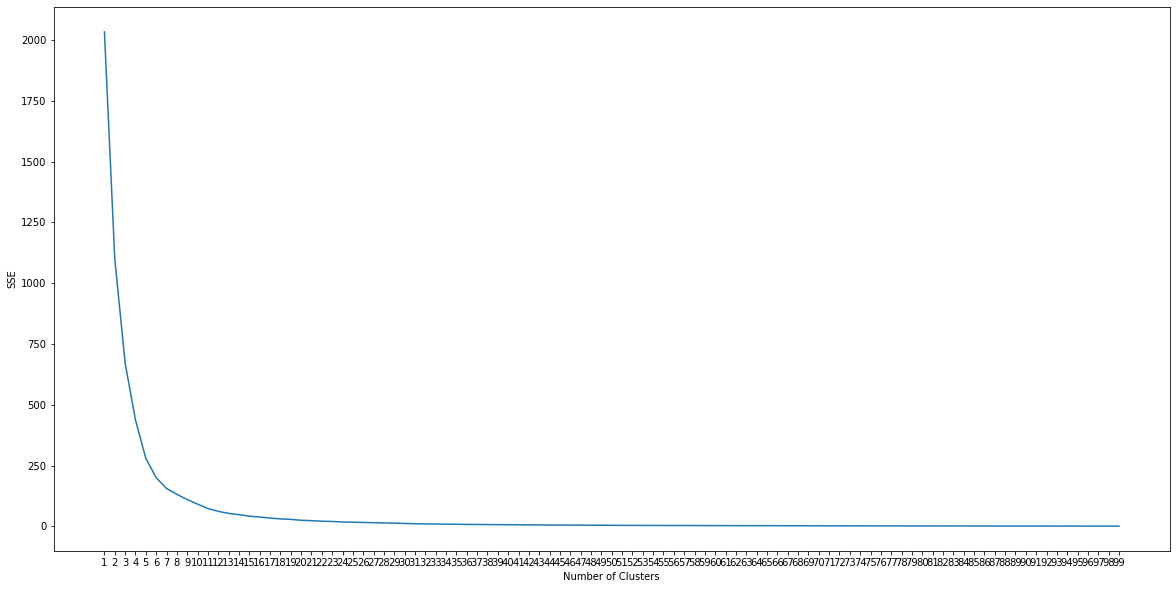

In [17]:
#Elbow:
#initialize kmeans parameters
kmeans_kwargs = {
"init": "random",
"n_init": 15,
"random_state": 1,
}

#create list to hold SSE values for each k
sse = []
for k in range(1, 100):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)
    
plt.figure(figsize=(20, 10))
#visualize results
plt.plot(range(1, 100), sse)
plt.xticks(range(1, 100))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

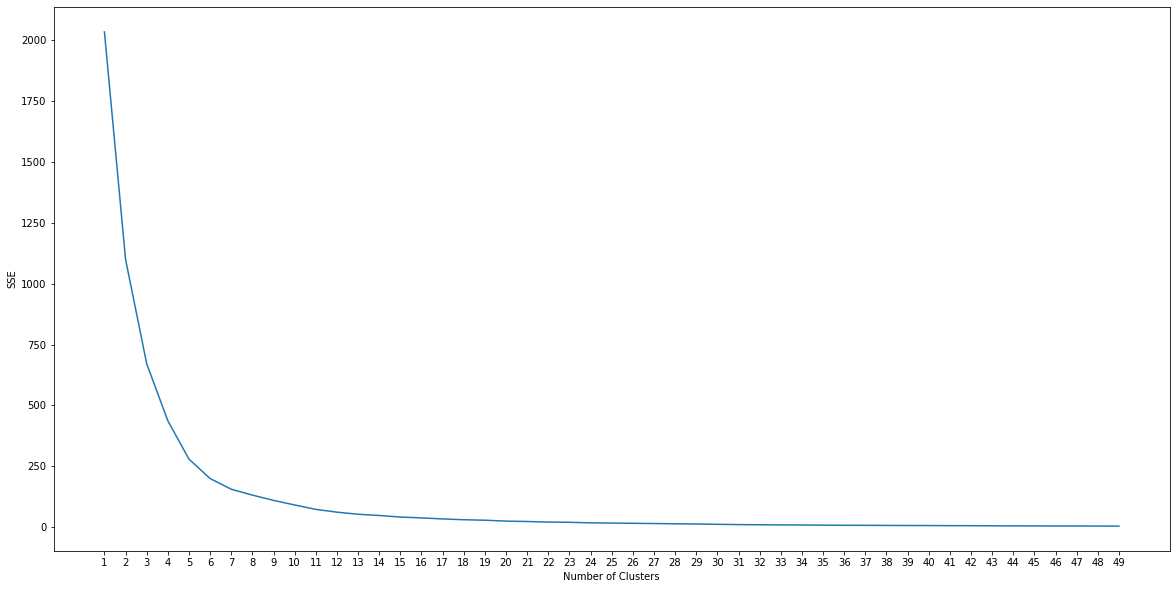

In [18]:
#create list to hold SSE values for each k
sse = []
for k in range(1, 50):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)
    
plt.figure(figsize=(20, 10))
#visualize results
plt.plot(range(1, 50), sse)
plt.xticks(range(1, 50))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [19]:
### cluster DARs
seed = 0
np.random.seed(seed)

n_clust = 50 #preselect number of clusters

kmeans = TimeSeriesKMeans(n_clusters=n_clust, max_iter=15, random_state=seed)
y_pred = kmeans.fit_predict(formatted_dataset)

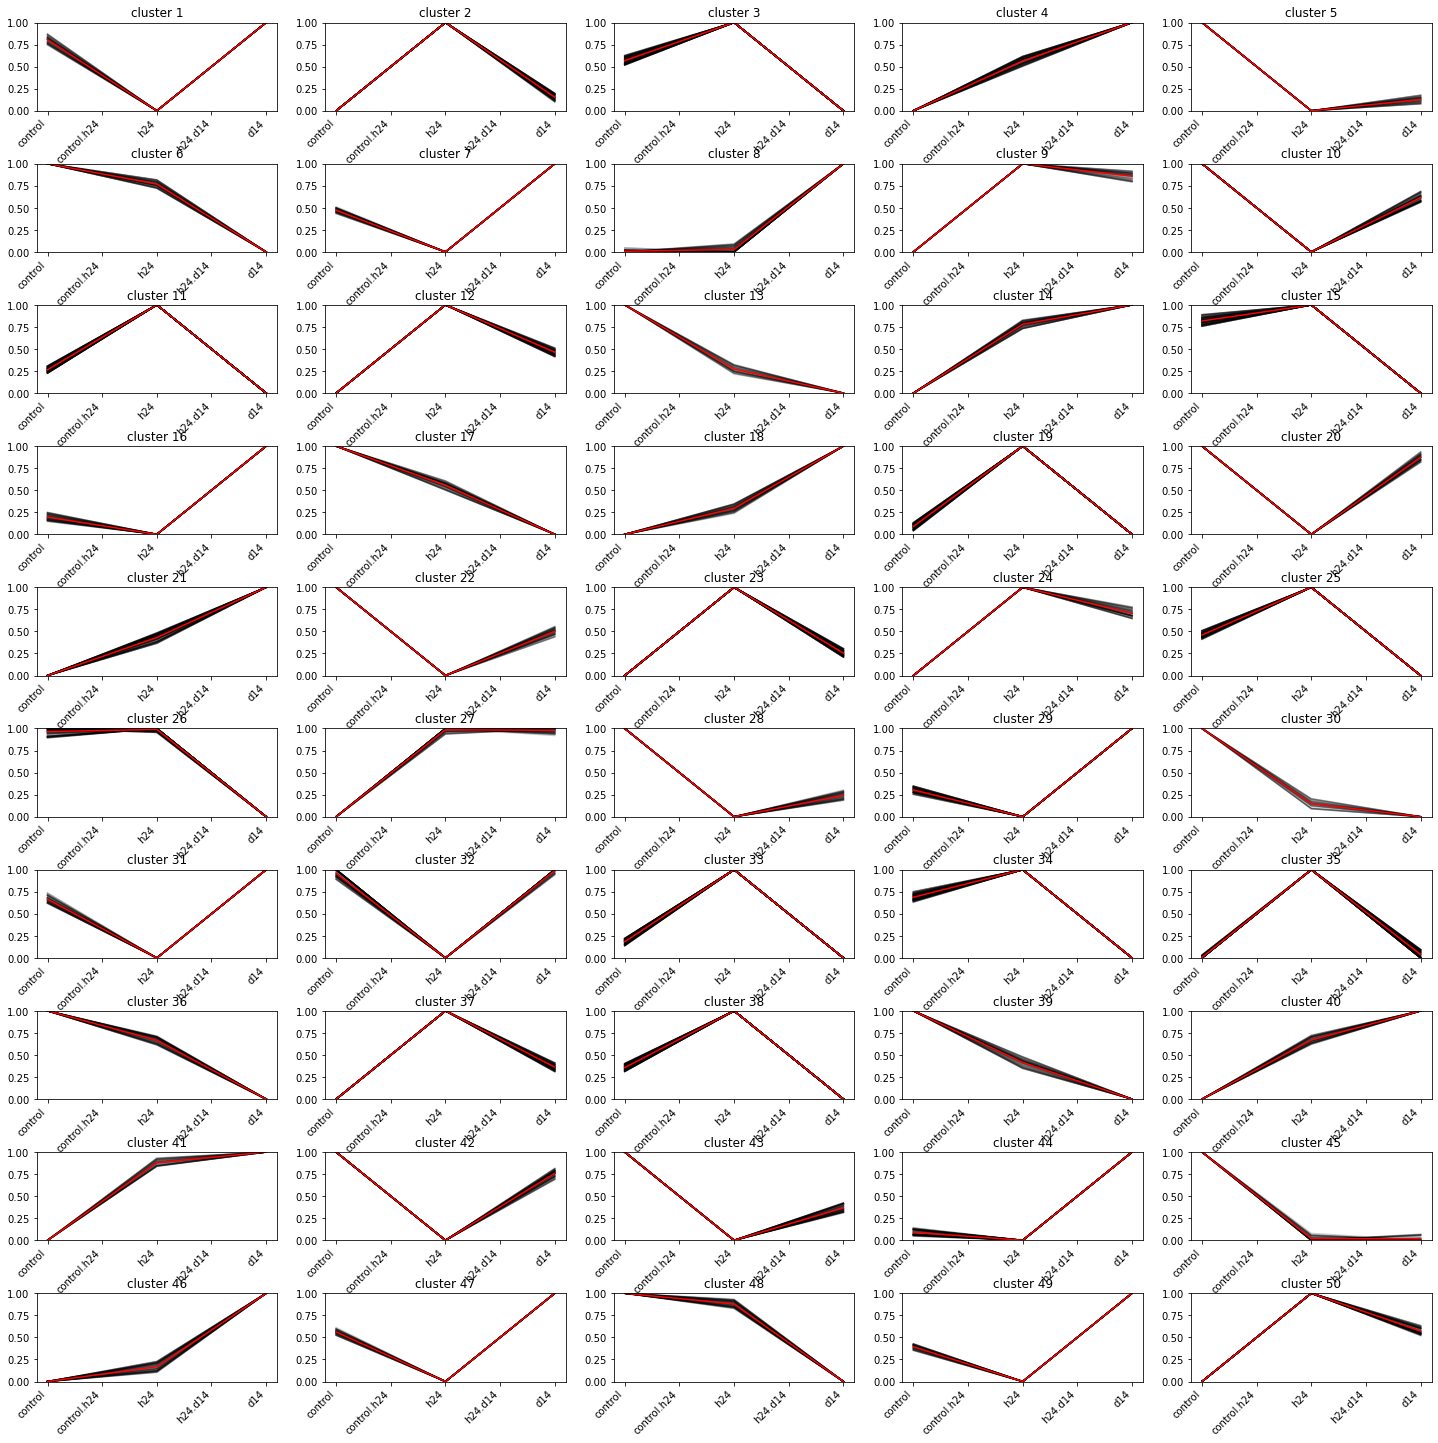

In [20]:
### plot clusters
fig, axs = plt.subplots(math.ceil(n_clust/5), 5,
                            figsize = (25,2.5*math.ceil(n_clust/5)),
                            gridspec_kw={'wspace':0.2, 'hspace':0.6})
axs = axs.ravel()
xticks = np.arange(len(desired_order))

for cluster in range(n_clust):

    for xx in formatted_dataset[y_pred == cluster]:
        axs[cluster].plot(xx.ravel(), "k-", alpha=.2)
    axs[cluster].plot(kmeans.cluster_centers_[cluster].ravel(), "r-")
    axs[cluster].set_ylim([0, 1])
    axs[cluster].set_xticks(xticks)
    axs[cluster].set_xticklabels(desired_order, rotation=45, ha='right')  
    #axs[cluster].set_xlim([0, 11])
    #axs[cluster].set_xticklabels(adata.obs["timepoint"].cat.categories)
    
    axs[cluster].title.set_text('cluster %d' % (cluster + 1))

### save figure
save_path = "/fast/AG_Pombo/luna/2023_vta_multiome/2024/2_ATAC/6_241113_ATACmemory_woh1sal/3_241113_kmeans/241115_final_lateDARs_allsamples.png"
fig.savefig(save_path, bbox_inches='tight', format='png', dpi=300)
    
plt.show()

In [22]:
### make dictionary with names of genes in each cluster
dynamic_cluster_dict = {}

for cluster in range(n_clust):
    dynamic_cluster_dict[f"cluster{str(cluster+1)}"] = modified_peakIDs[y_pred == cluster]

In [23]:
### print genes in cluster of interest
dynamic_cluster_dict['cluster18']

array(['chr1-23382475-23383608', 'chr1-78309963-78311336',
       'chr2-179848973-179850017', 'chr3-90464624-90465752',
       'chr3-121104634-121105190', 'chr3-154327825-154328745',
       'chr4-102005006-102005874', 'chr5-44784547-44785490',
       'chr7-123398633-123399154', 'chr9-106195693-106196029',
       'chr10-18318205-18319441', 'chr11-79644671-79645250',
       'chr12-72200469-72201319', 'chr13-23533575-23533904',
       'chr14-101839746-101840692', 'chr17-49836185-49836861',
       'chrX-103744278-103745133', 'chr1-165702398-165702983',
       'chr1-194808516-194809104', 'chr2-33085842-33086248',
       'chr2-91044779-91045417', 'chr2-174502495-174503090',
       'chr3-9407395-9408339', 'chr3-51233496-51234135',
       'chr4-62870423-62870931', 'chr4-130245996-130246407',
       'chr6-28397367-28398072', 'chr6-108326531-108327195',
       'chr7-135790834-135791275', 'chr9-41430094-41430978',
       'chr10-69909915-69910528', 'chr11-36494811-36495493',
       'chr11-49260467

In [24]:
#Code by Luna:
#I want to convert the dictionary to a dataframe and save it. 
dynamic_cluster_df = pd.DataFrame.from_dict(dynamic_cluster_dict, 'index').stack().reset_index(level=0)
dynamic_cluster_df[0] = dynamic_cluster_df[0].str.replace('-', ':', 1)

#Save it:
dynamic_cluster_df.to_csv('241115_DARs_memory_kmeans_version2_smooth.csv', index=False)  # Set index=False to exclude the index column

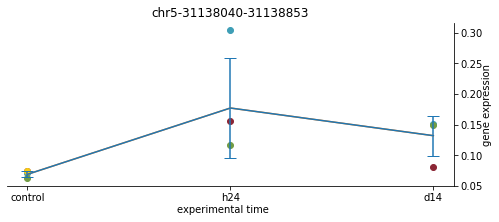

In [25]:
plot_gene_in_time(adata, 'chr5-31138040-31138853')